In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================================
# STEP 0 — Setup & Environment
# =========================================
!pip install timm -q
import os, shutil, time
import torch, timm
import torch.nn as nn
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================================
# STEP 1 — Copy dataset from Drive to local storage
# =========================================
src = "/content/drive/MyDrive/fisheye"
dst = "/content/fisheye"

if not os.path.exists(dst):
    print("Copying dataset from Drive to local storage...")
    shutil.copytree(src, dst)
else:
    print("Local dataset already exists.")

root = dst  # Use local path

# =========================================
# STEP 2 — Dataset Loading
# =========================================
all_data = datasets.ImageFolder(root=root)
train_idx, val_idx = train_test_split(
    range(len(all_data.targets)),
    test_size=0.2,
    stratify=all_data.targets,
    random_state=42
)

# Define transforms (resize slightly smaller for speed)
train_transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_data = datasets.ImageFolder(root=root, transform=train_transform)
val_data   = datasets.ImageFolder(root=root, transform=val_transform)

train_sampler = SubsetRandomSampler(train_idx)
val_sampler   = SubsetRandomSampler(val_idx)

# Improved DataLoader
common_loader_args = dict(
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)
train_loader = DataLoader(train_data, sampler=train_sampler, **common_loader_args)
val_loader   = DataLoader(val_data, sampler=val_sampler, **common_loader_args)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)

# =========================================
# STEP 3 — Custom ResNet50 Model
# =========================================
class CustomResNet50(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = timm.create_model("resnet50", pretrained=True, num_classes=0)
        self.head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x

model = CustomResNet50(num_classes=num_classes)
model = model.to(memory_format=torch.channels_last).to(device)

# =========================================
# STEP 4 — Training Utilities (Freeze / Unfreeze)
# =========================================
def freeze_backbone_train_head(model, bn_train=False):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.head.parameters():
        p.requires_grad = True
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
            m.train() if bn_train else m.eval()
    return model

def unfreeze_last_block(model, bn_train=False):
    for p in model.parameters():
        p.requires_grad = False
    for name, child in model.backbone.named_children():
        if name == "layer4":
            for p in child.parameters():
                p.requires_grad = True
    for p in model.head.parameters():
        p.requires_grad = True
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
            m.train() if bn_train else m.eval()
    return model

# =========================================
# STEP 5 — Train / Validate functions (with AMP)
# =========================================
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

scaler = torch.cuda.amp.GradScaler()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs = imgs.to(device, non_blocking=True).to(memory_format=torch.channels_last)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="Validating", leave=False):
        imgs = imgs.to(device, non_blocking=True).to(memory_format=torch.channels_last)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return total_loss / total, correct / total

# =========================================
# STEP 6 — Phase 1: Train Head Only
# =========================================
criterion = nn.CrossEntropyLoss()
model = freeze_backbone_train_head(model)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

epochs = 5
for epoch in range(epochs):
    print(f"\n[Phase 1 | Epoch {epoch+1}/{epochs}]")
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"Time per epoch: {(time.time()-start_time)/60:.1f} min")

print("✅ Training complete.")


Device: cuda
Copying dataset from Drive to local storage...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Classes: ['0', '1', '2', '3', '4']


/tmp/ipython-input-1690066393.py:133: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



[Phase 1 | Epoch 1/5]


...

Train Loss: 0.7223 | Train Acc: 0.7150
Val Loss:   0.6420 | Val Acc:   0.7612
Time per epoch: 3.3 min

[Phase 1 | Epoch 2/5]


Train Loss: 0.5753 | Train Acc: 0.7808
Val Loss:   0.5839 | Val Acc:   0.7751
Time per epoch: 3.3 min

[Phase 1 | Epoch 3/5]


Train Loss: 0.5300 | Train Acc: 0.8008
Val Loss:   0.5675 | Val Acc:   0.7876
Time per epoch: 3.4 min

[Phase 1 | Epoch 4/5]


Train Loss: 0.5020 | Train Acc: 0.8105
Val Loss:   0.5358 | Val Acc:   0.7988
Time per epoch: 3.4 min

[Phase 1 | Epoch 5/5]


Train Loss: 0.4832 | Train Acc: 0.8196
Val Loss:   0.5259 | Val Acc:   0.8077
Time per epoch: 3.4 min
✅ Training complete.


In [ ]:
# =========================================
# STEP 6 — Phase 2: Fine-tune Last Block + Head
# =========================================
model = unfreeze_last_block(model)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

for epoch in range(10):
    print(f"\n[Phase 2 | Epoch {epoch+1}]")
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


[Phase 2 | Epoch 1]


Training:   0%|          | 0/605 [00:00<?, ?it/s]/tmp/ipython-input-1690066393.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validating:   0%|          | 0/152 [00:00<?, ?it/s]/tmp/ipython-input-1690066393.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 0.4111 | Train Acc: 0.8476
Val Loss: 0.4509 | Val Acc: 0.8344

[Phase 2 | Epoch 2]


Train Loss: 0.3648 | Train Acc: 0.8686
Val Loss: 0.4065 | Val Acc: 0.8499

[Phase 2 | Epoch 3]


Train Loss: 0.3347 | Train Acc: 0.8783
Val Loss: 0.3948 | Val Acc: 0.8565

[Phase 2 | Epoch 4]


...

Train Loss: 0.2620 | Train Acc: 0.9064
Val Loss: 0.3111 | Val Acc: 0.8875

[Phase 2 | Epoch 7]


Train Loss: 0.2471 | Train Acc: 0.9120
Val Loss: 0.3035 | Val Acc: 0.8890

[Phase 2 | Epoch 8]


Train Loss: 0.2317 | Train Acc: 0.9163
Val Loss: 0.3010 | Val Acc: 0.8909

[Phase 2 | Epoch 9]


Train Loss: 0.2147 | Train Acc: 0.9225
Val Loss: 0.2696 | Val Acc: 0.9034

[Phase 2 | Epoch 10]


Train Loss: 0.2027 | Train Acc: 0.9275
Val Loss: 0.2608 | Val Acc: 0.9058


  with torch.cuda.amp.autocast():


=== Overall Metrics (Validation) ===
Accuracy : 0.9058
Precision (macro) : 0.8731
Recall    (macro) : 0.8465
F1-score  (macro) : 0.8585
Precision (weighted) : 0.9054
Recall    (weighted) : 0.9058
F1-score  (weighted) : 0.9053

=== Classification Report (per class) ===
              precision    recall  f1-score   support

           0     0.8095    0.8465    0.8276       241
           1     0.9232    0.9307    0.9269      4860
           2     0.9089    0.9180    0.9134      3609
           3     0.7571    0.7087    0.7321       642
           4     0.9667    0.8286    0.8923       315

    accuracy                         0.9058      9667
   macro avg     0.8731    0.8465    0.8585      9667
weighted avg     0.9054    0.9058    0.9053      9667

=== Per-class Accuracy ===
                   0: 0.8465
                   1: 0.9307
                   2: 0.9180
                   3: 0.7087
                   4: 0.8286


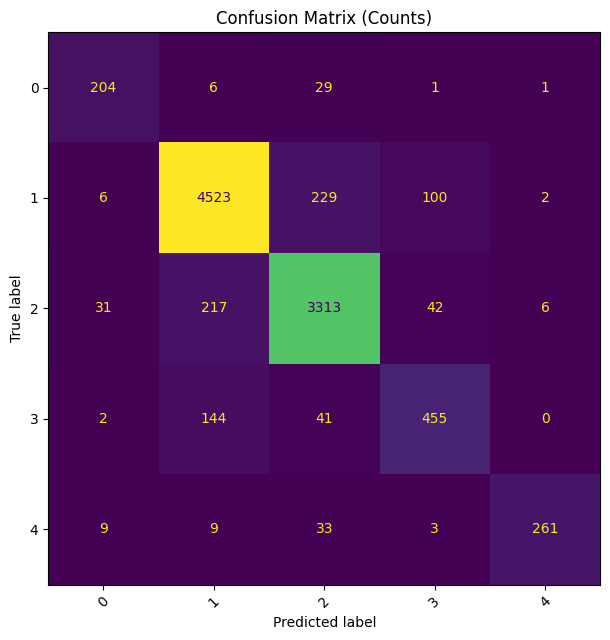

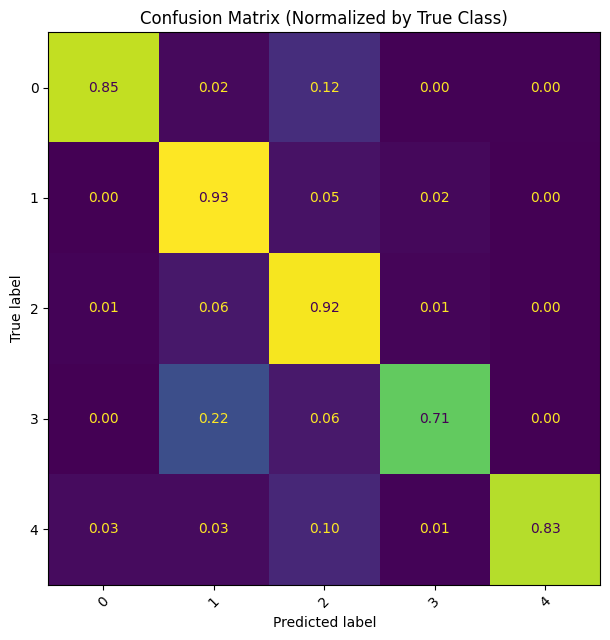


Macro ROC-AUC (OvR): 0.9829


In [ ]:
# =========================================
# STEP 7 — Final Evaluation (Validation set)
# =========================================
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_outputs(model, loader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for imgs, labels in tqdm(loader, desc="Collecting eval outputs", leave=False):
        imgs = imgs.to(device, non_blocking=True).to(memory_format=torch.channels_last)
        with torch.cuda.amp.autocast():
            logits = model(imgs)
            probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_labels.append(labels.cpu())
        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_prob = torch.cat(all_probs).numpy()  # shape: [N, num_classes]
    return y_true, y_pred, y_prob

y_true, y_pred, y_prob = collect_outputs(model, val_loader, device)
class_names = train_data.classes
num_classes = len(class_names)

#2) General metrics
acc = accuracy_score(y_true, y_pred)
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

print("=== Overall Metrics (Validation) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision (macro) : {prec_m:.4f}")
print(f"Recall    (macro) : {rec_m:.4f}")
print(f"F1-score  (macro) : {f1_m:.4f}")
print(f"Precision (weighted) : {prec_w:.4f}")
print(f"Recall    (weighted) : {rec_w:.4f}")
print(f"F1-score  (weighted) : {f1_w:.4f}")

# 3) Classification report by class
print("\n=== Classification Report (per class) ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

# 4) per-class accuracy
per_class_acc = []
for c in range(num_classes):
    idx = (y_true == c)
    acc_c = (y_pred[idx] == c).mean() if idx.sum() > 0 else float("nan")
    per_class_acc.append(acc_c)
print("=== Per-class Accuracy ===")
for name, a in zip(class_names, per_class_acc):
    print(f"{name:>20s}: {a:.4f}")

# 5) Confusion matrix (raw & normalized)
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
cm_norm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize='true')

fig, ax = plt.subplots(figsize=(6.5, 6.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("Confusion Matrix (Counts)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 6.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, values_format=".2f")
ax.set_title("Confusion Matrix (Normalized by True Class)")
plt.tight_layout()
plt.show()

# ROC-AUC macro for multi-class (one-vs-rest)
try:
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_auc_score
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    if y_true_bin.shape[1] == num_classes:
        auc_macro = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
        print(f"\nMacro ROC-AUC (OvR): {auc_macro:.4f}")
except Exception as e:
    print("\n[Info] ROC-AUC not computed:", e)


In [ ]:
torch.save(model.state_dict(), "best_resnet50_finetuned.pth")


In [ ]:
from google.colab import files
files.download("best_resnet50_finetuned.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>